# Figure 3: Disease associations of fldAIBC carriers

This notebook reproduces the four non-empty plotting cells in the supplied
Figure 3 notebook, in their original order: **a, b, c, d**. Panel d combines
lineage contrasts and exposure-definition robustness. The older five-panel
description does not define the numbering used here.

Inputs are frozen processed TSV tables in `../data/figure3/`. No upstream
statistical models are rerun. Figures are written to `../outputs/figure3/`
as SVG, PDF, PNG and TIFF. Run all cells from top to bottom.

| Panel | Content | Packaged inputs |
|---|---|---|
| a | Disease association landscape | `figure3a_disease.tsv` |
| b | CRC cohort forest plot | `figure3b_cohort_effects.tsv`, `figure3b_pooled_effects.tsv` |
| c | Coarse-to-resolved carriage prevalence | `figure3c_prevalence.tsv` |
| d | Lineage association robustness and direct contrasts | `figure3d_lineage_contrasts.tsv`, `figure3d_exposure_robustness.tsv` |

The source tables retain their original values, estimator definitions and
statistical columns. In panel b, the original plotting code excludes
ERP110064 because it has no informative carrier events; the pooled estimate
is read unchanged from the frozen summary table. In panel d, arcs represent
direct contrasts with FDR q < 0.05 and markers show the Any, Dominant and
Single carriage definitions.


## Setup

Resolve packaged paths and load the original publication style.

In [1]:
from pathlib import Path
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

%matplotlib inline

# The original Arial font contains an optional metadata table that PDF export drops.
logging.getLogger("fontTools.subset").setLevel(logging.ERROR)

# Run from either the repository root or the notebooks directory.
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
DATA_DIR = REPO_ROOT / "data" / "figure3"
OUTPUT_DIR = REPO_ROOT / "outputs" / "figure3"
if not DATA_DIR.is_dir():
    raise FileNotFoundError("Run from the repository root or its notebooks directory.")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TICK_FS = 7
AXIS_FS = 8
LEGEND_FS = 7
PANEL_FS = 10.5
BLUE = "#243B59"
ORANGE = "#C75B21"
GRAY = "#858585"
LIGHT_GRAY = "#BFC5CC"

# Arial is the original font. The fallback makes the notebook portable.
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "mathtext.default": "regular",
    "font.size": TICK_FS,
    "axes.labelsize": AXIS_FS,
    "xtick.labelsize": TICK_FS,
    "ytick.labelsize": TICK_FS,
    "legend.fontsize": LEGEND_FS,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 1.0,
})


def save_pub_figure(fig, output_stem, width_mm, height_mm, dpi=600):
    """Retain the original sizing compensation and four export formats."""
    pad_inches = 0.02
    target_w = width_mm / 25.4
    target_h = height_mm / 25.4
    fig.set_size_inches(target_w, target_h)
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    tight_bbox = fig.get_tightbbox(renderer)
    actual_w = tight_bbox.width + 2 * pad_inches
    actual_h = tight_bbox.height + 2 * pad_inches
    dw = target_w - actual_w
    dh = target_h - actual_h
    fig.set_size_inches(target_w + dw, target_h + dh)
    output_stem.parent.mkdir(parents=True, exist_ok=True)
    for suffix in (".svg", ".pdf", ".png", ".tiff"):
        fig.savefig(
            output_stem.with_suffix(suffix), dpi=dpi, bbox_inches="tight",
            pad_inches=pad_inches, facecolor="white",
        )


## Panel a: Disease association landscape

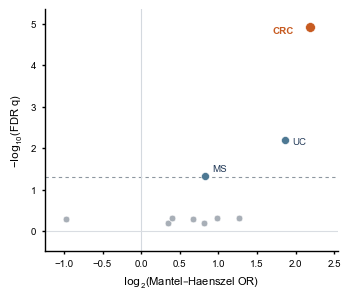

In [2]:
# Original panel dimensions in millimetres.
WIDTH_MM = 87.06
HEIGHT_MM = 74.771

required_files = [
    DATA_DIR / "figure3a_disease.tsv",
]
df = pd.read_csv(required_files[0], sep="\t")
estimable = df.loc[df["is_estimable"].astype(str).str.lower().eq("true")].copy()
estimable["log2_primary_or"] = pd.to_numeric(estimable["log2_primary_or"], errors="coerce")
estimable["fdr_q"] = pd.to_numeric(estimable["fdr_q"], errors="coerce")
estimable = estimable.dropna(subset=["log2_primary_or", "fdr_q"])
estimable = estimable.loc[estimable["fdr_q"] > 0].copy()
estimable["minus_log10_q"] = -np.log10(estimable["fdr_q"])
if estimable.empty or "CRC" not in estimable["disease"].values:
    raise RuntimeError("Figure 3a source lacks estimable disease effects or CRC.")

fig, ax = plt.subplots()

# Set the initial plot margins before tight-bbox export.
fig.subplots_adjust(left=0.18, right=0.96, top=0.91, bottom=0.18)

q_cutoff = -np.log10(0.05)
ax.axhline(q_cutoff, color="#8D969F", lw=0.8, ls=(0, (3, 3)), zorder=0)
ax.axvline(0, color="#D4D9DF", lw=0.8, zorder=0)

for row in estimable.itertuples():
    if row.disease == "CRC":
        color, size, zorder = ORANGE, 50, 4
    elif row.fdr_q < 0.05:
        color, size, zorder = "#4D7893", 33, 3
    else:
        color, size, zorder = "#A8AFB7", 23, 2
    ax.scatter(row.log2_primary_or, row.minus_log10_q, s=size, color=color,
               edgecolor="white", linewidth=0.4, zorder=zorder)

for disease, offset in {"CRC": (-27, -3), "UC": (5, -2), "MS": (5, 5)}.items():
    row = estimable.loc[estimable["disease"] == disease]
    if not row.empty:
        point = row.iloc[0]
        ax.annotate(disease, (point["log2_primary_or"], point["minus_log10_q"]),
                    xytext=offset, textcoords="offset points", fontsize=TICK_FS,
                    color=ORANGE if disease == "CRC" else BLUE,
                    fontweight="bold" if disease == "CRC" else "normal",
                    va="center")

not_estimable = df.loc[~df["is_estimable"].astype(str).str.lower().eq("true"), "disease"].tolist()
ax.set_ylim(-0.47, max(5.35, estimable["minus_log10_q"].max() + 0.32))
ax.set_xlim(min(-1.25, estimable["log2_primary_or"].min() - 0.2),
            max(2.55, estimable["log2_primary_or"].max() + 0.15))

ax.axhline(0, color="#D9DDE2", lw=0.8)

ax.set_xlabel(r"$\log_2$(Mantel–Haenszel OR)", fontsize=AXIS_FS)
ax.set_ylabel(r"$-\log_{10}$(FDR q)", fontsize=AXIS_FS)

ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(length=2.5, width=1.0, labelsize=TICK_FS)

# Export at the specified panel dimensions.
save_pub_figure(fig, OUTPUT_DIR / "Figure3a", WIDTH_MM, HEIGHT_MM)


## Panel b: CRC cohort forest plot

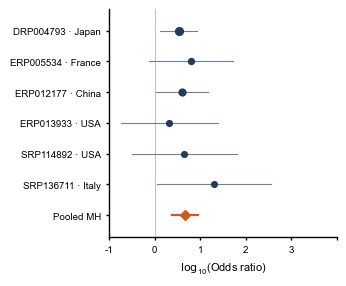

In [3]:
# Original panel dimensions in millimetres.
WIDTH_MM = 92.848
HEIGHT_MM = 74

required_files = [
    DATA_DIR / "figure3b_cohort_effects.tsv",
    DATA_DIR / "figure3b_pooled_effects.tsv",
]
df = pd.read_csv(required_files[0], sep="\t")
summary = pd.read_csv(required_files[1], sep="\t")
pool = summary.loc[summary.feature == "All_FLD"].iloc[0]

# Omit ERP110064 (Germany), which has no informative carrier events.
df = df[df['study'] != 'ERP110064'].copy()

fig, ax = plt.subplots()
# Set the initial margins for the cohort forest plot.
fig.subplots_adjust(left=0.45, right=0.97, top=0.95, bottom=0.18) 

y = np.arange(len(df), 0, -1)
# The null odds ratio is zero after the log10 transformation.
# Use a thin neutral reference line.
ax.axvline(0, color="#BFC5CC", lw=0.8)

informative = df.informative.astype(bool)
weight_total = (1 / df.loc[informative, "se"].astype(float) ** 2).sum()

for yi, (_, row) in zip(y, df.iterrows()):
    if bool(row.informative):
        # Transform each cohort estimate and interval to log10.
        log_lower = np.log10(row.lower)
        log_upper = np.log10(row.upper)
        log_est = np.log10(row.estimate)
        
        # Draw the cohort confidence interval.
        ax.plot([log_lower, log_upper], [yi, yi], color="#718093", lw=0.8)
        point_size = 15 + 35 * (1 / row.se ** 2) / weight_total
        ax.scatter(log_est, yi, s=point_size, color=BLUE, zorder=3)

# Transform the pooled estimate and interval to log10.
log_pool_lower = np.log10(pool.mh_lower)
log_pool_upper = np.log10(pool.mh_upper)
log_pool_or = np.log10(pool.mh_or)

ax.plot([log_pool_lower, log_pool_upper], [0, 0], color=ORANGE, lw=1.6)
ax.plot(log_pool_or, 0, "D", color=ORANGE, ms=5)

# Include country names in the cohort labels.
cohort_labels = [f"{row.study} · {str(row.country).replace('United States of America', 'USA')}" for _, row in df.iterrows()]

# Use 7-point cohort labels.
ax.set_yticks([*y, 0], [*cohort_labels, "Pooled MH"], fontsize=7)
ax.set_ylim(-0.7, len(df) + 0.7)

# Keep the original x-axis range and leave the final tick unlabelled.
ax.set_xlim(-1, 4)
ax.set_xticks([-1, 0, 1, 2, 3, 4])
ax.set_xticklabels(['-1', '0', '1', '2', '3', '']) # Leave the final tick unlabelled.
ax.set_xlabel(r"$\log_{10}$(Odds ratio)", fontsize=8)

# Keep a square plotting area, excluding the labels.
ax.set_box_aspect(1)

ax.spines[["top", "right"]].set_visible(False)

# Match tick labels and tick widths to the panel style.
ax.tick_params(axis='x', length=2.5, width=1.0, labelsize=7)
ax.tick_params(axis='y', length=2.5, width=1.0, labelsize=7)

# Export at the specified panel dimensions.
save_pub_figure(fig, OUTPUT_DIR / "Figure3b", WIDTH_MM, HEIGHT_MM)


## Panel c: Coarse-to-resolved carriage prevalence

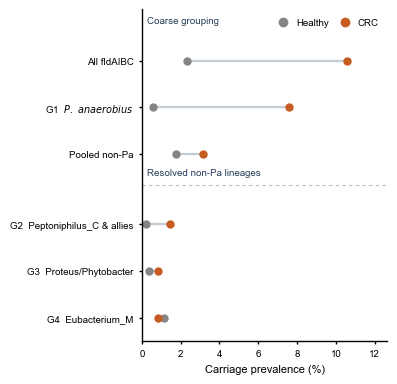

In [4]:
# Original panel dimensions in millimetres.
WIDTH_MM = 95.652
HEIGHT_MM = 98.79

required_files = [
    DATA_DIR / "figure3c_prevalence.tsv",
]
df = pd.read_csv(required_files[0], sep="\t").sort_values("row_order")
fig, ax = plt.subplots()

# Use the original prevalence-panel margins without a fixed box aspect.
fig.subplots_adjust(left=0.29, right=0.97, top=0.86, bottom=0.14)

y = np.array([6, 5, 4, 2.5, 1.5, 0.5])
for i, (_, row) in enumerate(df.iterrows()):
    ax.plot([row.pct_control, row.pct_case], [y[i], y[i]], color="#C6CDD2", lw=1.6, zorder=1)
    ax.plot(row.pct_control, y[i], "o", color=GRAY, ms=5, zorder=2)
    ax.plot(row.pct_case, y[i], "o", color=ORANGE, ms=5, zorder=3)

# Separate coarse and resolved lineage groups.
ax.axhline(3.35, color="#B7BDC5", lw=0.8, ls=(0, (3, 3)))

ax.text(0.02, 0.98, "Coarse grouping", transform=ax.transAxes, ha="left", va="top", fontsize=LEGEND_FS, color=BLUE)
ax.text(0.02, 0.52, "Resolved non-Pa lineages", transform=ax.transAxes, ha="left", va="top", fontsize=LEGEND_FS, color=BLUE)

display_labels = df.display_label.tolist()
display_labels[1] = r"G1  $\it{P.\ anaerobius}$"
ax.set_yticks(y, display_labels, fontsize=TICK_FS)

# Keep the original lower y-axis limit to minimize empty space.
ax.set_ylim(0, 7.1)

ax.set_xlim(0, max(df.pct_case.max(), df.pct_control.max()) * 1.2)
ax.set_xlabel("Carriage prevalence (%)", fontsize=AXIS_FS)

ax.plot([], [], "o", color=GRAY, label="Healthy")
ax.plot([], [], "o", color=ORANGE, label="CRC")
ax.legend(frameon=False, loc="upper right", ncol=2, handletextpad=0.3, columnspacing=0.7, fontsize=LEGEND_FS)

ax.spines[["top", "right"]].set_visible(False)

# Apply the common tick width and font size.
ax.tick_params(axis='both', length=2.5, width=1.0, labelsize=TICK_FS)

# Export at the specified panel dimensions.
save_pub_figure(fig, OUTPUT_DIR / "Figure3c", WIDTH_MM, HEIGHT_MM)


## Panel d: Lineage robustness and direct contrasts

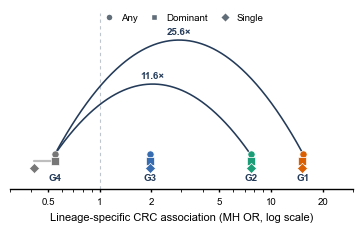

In [5]:
# Original panel dimensions in millimetres.
WIDTH_MM = 88.9
HEIGHT_MM = 58.4

LINEAGE_COLORS = {
    "G1": "#D95F02",
    "G2": "#1B9E77",
    "G3": "#386CB0",
    "G4": "#777777",
}

MODES = ["Any", "Dominant", "Single"]

MARKERS = {
    "Any": "o",
    "Dominant": "s",
    "Single": "D",
}

# Offset exposure-definition markers vertically for legibility.
MODE_Y = {
    "Any": 0.115,
    "Dominant": 0.060,
    "Single": 0.005,
}




    


def normalize_lineage(value):

    value = str(value)

    if value.startswith("G1"):
        return "G1"

    if value.startswith("G2"):
        return "G2"

    if value.startswith("G3"):
        return "G3"

    if value.startswith("G4"):
        return "G4"

    return value


def arc_points(x1, x2, base_y, height, n=250):

    lo = min(x1, x2)
    hi = max(x1, x2)

    # Use geometric interpolation for symmetric arcs on the log axis.
    xs = np.geomspace(lo, hi, n)

    t = np.linspace(0, 1, n)

    ys = (
        base_y
        + height * 4 * t * (1 - t)
    )

    return xs, ys


# =========================================================
# Load data
# =========================================================
df_contrast = pd.read_csv(
    DATA_DIR / "figure3d_lineage_contrasts.tsv",
    sep="\t",
)

df_robust = pd.read_csv(
    DATA_DIR / "figure3d_exposure_robustness.tsv",
    sep="\t",
)


# =========================================================
# Validate estimator
# =========================================================
if (
    df_robust["estimator"].nunique() != 1
    or "Mantel" not in str(df_robust["estimator"].iloc[0])
):
    raise RuntimeError(
        "Figure 3 robustness source mixes or changes the OR estimator."
    )


# =========================================================
# Prepare robustness data
# =========================================================
df_robust = df_robust.copy()

df_robust["G"] = (
    df_robust["lineage"]
    .map(normalize_lineage)
)

df_robust = df_robust[
    df_robust["G"].isin(
        ["G1", "G2", "G3", "G4"]
    )
    &
    df_robust["exposure_definition"].isin(
        MODES
    )
].copy()

df_robust["OR"] = pd.to_numeric(
    df_robust["OR"],
    errors="coerce"
)

expected_lineages = [
    "G1",
    "G2",
    "G3",
    "G4",
]

or_lookup = {}

for lineage in expected_lineages:

    subset = (
        df_robust.loc[
            df_robust["G"] == lineage
        ]
        .set_index("exposure_definition")
        .loc[MODES]
    )

    values = (
        subset["OR"]
        .to_numpy(float)
    )

    if (
        not np.all(np.isfinite(values))
        or np.any(values <= 0)
    ):
        raise RuntimeError(
            f"Invalid MH OR values for {lineage}"
        )

    or_lookup[lineage] = {
        mode: float(
            subset.loc[
                mode,
                "OR"
            ]
        )
        for mode in MODES
    }


# =========================================================
# Significant direct contrasts
# =========================================================
contrast = df_contrast.copy()

contrast["row_G"] = (
    contrast["row_feature"]
    .map(normalize_lineage)
)

contrast["col_G"] = (
    contrast["column_feature"]
    .map(normalize_lineage)
)

contrast["or_ratio"] = pd.to_numeric(
    contrast["or_ratio"],
    errors="coerce"
)

contrast["q_value"] = pd.to_numeric(
    contrast["q_value"],
    errors="coerce"
)

sig = contrast.loc[
    contrast["q_value"] < 0.05
].copy()


# =========================================================
# Plot
# =========================================================
fig, ax = plt.subplots()

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.87,
    bottom=0.22,
)

ax.set_xscale("log")

ax.set_xlim(
    0.30,
    30
)

ax.set_ylim(
    -0.16,
    1.24
)

# OR = 1
ax.axvline(
    1,
    color=LIGHT_GRAY,
    lw=0.8,
    ls=(0, (3, 3)),
    zorder=0,
)


# =========================================================
# Draw four lineage clusters
# =========================================================
for lineage in expected_lineages:

    color = LINEAGE_COLORS[lineage]

    values = np.array([
        or_lookup[lineage][mode]
        for mode in MODES
    ])

    # robustness span
    ax.plot(
        [
            values.min(),
            values.max()
        ],
        [
            0.060,
            0.060
        ],
        color=color,
        lw=1.6,
        alpha=0.48,
        solid_capstyle="round",
        zorder=1,
    )

    # Any / Dominant / Single
    for mode in MODES:

        ax.scatter(
            or_lookup[lineage][mode],
            MODE_Y[mode],
            marker=MARKERS[mode],
            s=27,
            facecolor=color,
            edgecolor="white",
            linewidth=0.5,
            zorder=4,
        )

    # lineage label below cluster
    any_or = or_lookup[lineage]["Any"]

    ax.text(
        any_or,
        -0.035,
        lineage,
        ha="center",
        va="top",
        fontsize=TICK_FS,
        color=BLUE,
        fontweight="bold",
    )


# =========================================================
# Significant pairwise contrast arcs
#
# Arc endpoints use Any-definition MH OR.
# =========================================================
arc_rows = []

for _, row in sig.iterrows():

    g1 = row["row_G"]
    g2 = row["col_G"]

    if (
        g1 not in or_lookup
        or g2 not in or_lookup
    ):
        continue

    x1 = or_lookup[g1]["Any"]
    x2 = or_lookup[g2]["Any"]

    span = abs(
        np.log10(x1)
        - np.log10(x2)
    )

    arc_rows.append({
        "g1": g1,
        "g2": g2,
        "x1": x1,
        "x2": x2,
        "ratio": float(row["or_ratio"]),
        "q": float(row["q_value"]),
        "span": span,
    })

arc_rows = sorted(
    arc_rows,
    key=lambda x: x["span"],
    reverse=True,
)

# expected two significant contrasts;
# widest arc higher
ARC_HEIGHTS = [
    0.91,
    0.56,
    0.34,
]

for i, row in enumerate(arc_rows):

    height = (
        ARC_HEIGHTS[i]
        if i < len(ARC_HEIGHTS)
        else 0.30
    )

    xs, ys = arc_points(
        row["x1"],
        row["x2"],
        base_y=MODE_Y["Any"],
        height=height,
    )

    ax.plot(
        xs,
        ys,
        color=BLUE,
        lw=1.15,
        zorder=2,
    )

    x_mid = np.sqrt(
        row["x1"]
        * row["x2"]
    )

    ax.text(
        x_mid,
        MODE_Y["Any"]
        + height
        + 0.035,
        f"{row['ratio']:.1f}×",
        ha="center",
        va="bottom",
        fontsize=LEGEND_FS,
        color=BLUE,
        fontweight="bold",
    )


# =========================================================
# Legend
# =========================================================
legend_handles = [

    Line2D(
        [0], [0],
        linestyle="none",
        marker=MARKERS[mode],
        markersize=5,
        markerfacecolor="#616D78",
        markeredgecolor="white",
        label=mode,
    )

    for mode in MODES
]

ax.legend(
    handles=legend_handles,
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.50, 1.05),
    handletextpad=0.25,
    columnspacing=0.70,
    fontsize=LEGEND_FS,
)


# =========================================================
# Axis
# =========================================================
ax.set_xlabel(
    "Lineage-specific CRC association (MH OR, log scale)",
    fontsize=AXIS_FS,
)

ax.set_yticks([])

ax.set_xticks([
    0.5,
    1,
    2,
    5,
    10,
    20,
])

ax.set_xticklabels([
    "0.5",
    "1",
    "2",
    "5",
    "10",
    "20",
])

for spine in [
    "top",
    "right",
    "left",
]:
    ax.spines[spine].set_visible(False)

ax.spines[
    "bottom"
].set_linewidth(1.0)

ax.tick_params(
    axis="x",
    length=2.5,
    width=1.0,
    labelsize=TICK_FS,
)

ax.tick_params(
    axis="y",
    length=0,
)


# =========================================================
# Save
# =========================================================
save_pub_figure(
    fig,
    OUTPUT_DIR / "Figure3d",
    WIDTH_MM,
    HEIGHT_MM,
)
